# Source localization 

The aim of this lecture is to teach you how to compute and apply
a linear inverse method such as MNE/dSPM/sLORETA on evoked/raw/epochs data.

`
Authors: Marijn van Vliet, Britta Westner, Alexandre Gramfort, Denis Engemann 
`

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import mne

# Change the following path to where the folder ds000117 is on your disk.
data_path = "./ds000117_pruned"  # `./` means the folder of this notebook

# Change the following path to where you unzipped the extra data (`extra_meg_data.zip`) on your disk.
extra_path = "./extra_data_mne"  # `./` means the folder of this notebook

## Read epochs and compute ERP/ERF

In [2]:
epochs_fname = f"{data_path}/derivatives/meg_derivatives/sub-01/ses-meg/meg/sub-01_ses-meg_task-facerecognition_run-01_proc-sss-epo.fif"
epochs = mne.read_epochs(epochs_fname)
epochs.info

Reading /home/vanvlm1/projects/mne_practical_meeg_2025/ds000117_pruned/derivatives/meg_derivatives/sub-01/ses-meg/meg/sub-01_ses-meg_task-facerecognition_run-01_proc-sss-epo.fif ...
    Found the data of interest:
        t =    -466.67 ...    2033.33 ms
        0 CTF compensation matrices available
Not setting metadata
79 matching events found
No baseline correction applied
0 projection items activated


<Info | 24 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: []
 ch_names: MEG0113, MEG0112, MEG0111, MEG0122, MEG0123, MEG0121, MEG0132, ...
 chs: 204 Gradiometers, 102 Magnetometers, 70 EEG, 2 EOG
 custom_ref_applied: True
 description: (meg) Vectorview system at Cambridge
 dev_head_t: MEG device -> head transform
 dig: 137 items (3 Cardinal, 5 HPI, 75 EEG, 54 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 hpi_subsystem: 2 items (dict)
 line_freq: 50.0
 lowpass: 40.0 Hz
 meas_date: 1941-03-22 11:04:14 UTC
 meas_id: 4 items (dict)
 nchan: 378
 proc_history: 1 item (list)
 proj_id: 47
 proj_name: dgw_studies
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | id: 813, birthday: 1978-01-01>
>

In [3]:
# since we computed our forward model for MEG only, we drop the EEG channels
epochs.pick_types(meg=True, eeg=False)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


<EpochsFIF | 79 events (all good), -0.467 – 2.033 s (baseline -0.2 – 0 s), ~145.4 MiB, data loaded,
 'face/famous/first': 13
 'face/famous/immediate': 3
 'face/famous/long': 6
 'face/unfamiliar/first': 17
 'face/unfamiliar/immediate': 4
 'face/unfamiliar/long': 6
 'scrambled/first': 15
 'scrambled/immediate': 9
 'scrambled/long': 6>

Let's compute the evoked responses for several conditions: _all_, _faces_  and  _scrambled_

In [4]:
evoked_all = epochs.average().crop(-0.05, 0.4)
evoked_face = epochs["face"].average().crop(-0.05, 0.4)
evoked_scrambled = epochs["scrambled"].average().crop(-0.05, 0.4)

Compute the contrast between the two _faces_ and _scrambled_ conditions:

Fitted sphere radius:         86.5 mm
Origin head coordinates:      4.2 6.0 42.4 mm
Origin device coordinates:    1.7 14.7 -5.5 mm


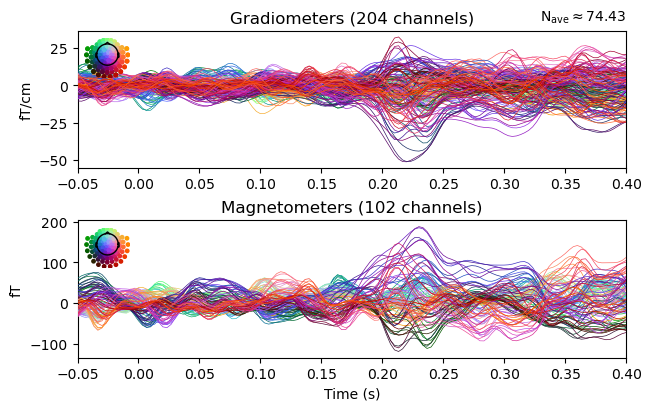

In [5]:
evoked_contrast = mne.combine_evoked([evoked_face, evoked_scrambled], [0.5, -0.5])

# Fit a sphere to the headshape in order to make proper topo plots.
# This is needed for this particular dataset and may not be necessary for yours.
radius, center, _ = mne.bem.fit_sphere_to_headshape(epochs.info, dig_kinds="eeg")
sphere = tuple(center) + (radius,)

# Plot the contrast.
evoked_contrast.plot(sphere=sphere);

## Prepare for source estimation

In order to perform source estimation, we first need to estimate the covariance between the sensors.
This is typically done on a stretch of data without experimental effects, containing only "noise", hence we refer to this covariance matrix as the "noise covariance".
In many cases, we can use the baseline period for this.

In [6]:
noise_cov = mne.compute_covariance(epochs, tmin=-.25, tmax=0.,  # use the baseline
                                   rank="info")

    Setting small MEG eigenvalues to zero (without PCA)
Reducing data rank from 306 -> 68
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 6004
[done]


Let's visualize our covariance matrices. We can see that they are severly rank deficient. Can you guess why?

Let's keep a mental note that we may have to take this into account later!

Computing rank from covariance with rank=None
    Using tolerance 1.8e-14 (2.2e-16 eps * 102 dim * 0.79  max singular value)
    Estimated rank (mag): 68
    MAG: rank 68 computed from 102 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 1.4e-13 (2.2e-16 eps * 204 dim * 3.1  max singular value)
    Estimated rank (grad): 68
    GRAD: rank 68 computed from 204 data channels with 0 projectors


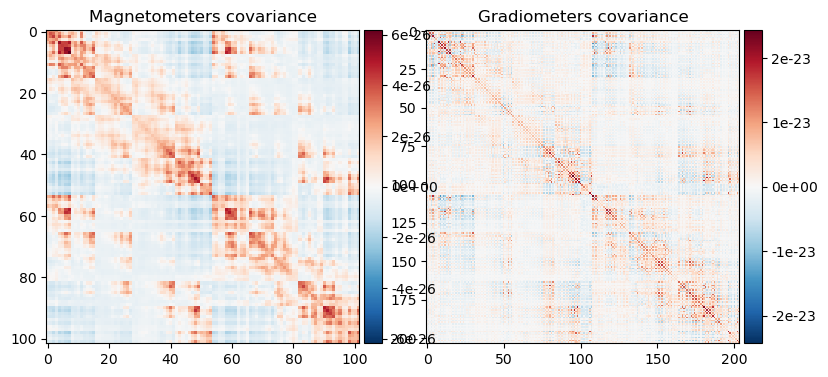

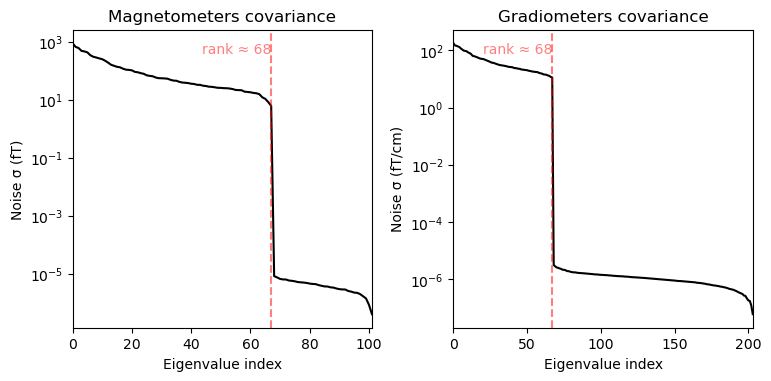

(<Figure size 760x370 with 4 Axes>, <Figure size 760x370 with 2 Axes>)

In [7]:
mne.viz.plot_cov(noise_cov, info=epochs.info)

We can visualize the whitening of the evoked data, using this noise covariance matrix:

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Computing rank from covariance with rank=None
    Using tolerance 2.6e-13 (2.2e-16 eps * 306 dim * 3.9  max singular value)
    Estimated rank (mag + grad): 68
    MEG: rank 68 computed from 306 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 2.6e-13 (2.2e-16 eps * 306 dim * 3.9  max singular value)
    Estimated rank (mag + grad): 68
    MEG: rank 68 computed from 306 data channels with 0 projectors
SSS has been applied to data. Showing mag and grad whitening jointly.
Computing rank from covariance with rank={'meg': 68}
    Setting small MEG eigenvalues to zero (without PCA)
    Created the whitener using a noise covariance matrix with rank 68 (238 small eigenvalues omitted)


/tmp/ipykernel_2000330/2155578127.py:2: RuntimeWarning: (X, Y) fit (3.3, 36.9) more than 20 mm from head frame origin
  evoked_all.plot_white(noise_cov, sphere=sphere);


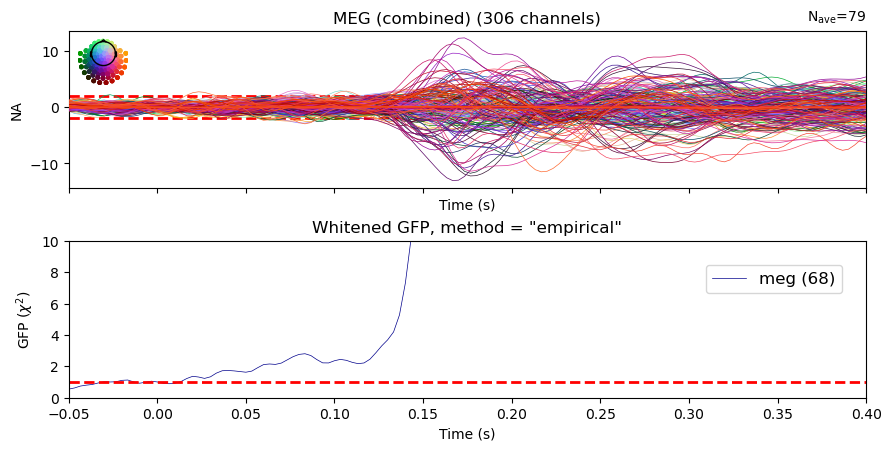

In [11]:
%matplotlib inline
evoked_all.plot_white(noise_cov, sphere=sphere);

Loading surfaces...

Loading the solution matrix...

Homogeneous model surface loaded.
Loaded linear collocation BEM solution from /home/vanvlm1/projects/mne_practical_meeg_2025/extra_data_mne/source_recon/sub-01/sub-01-bem.fif


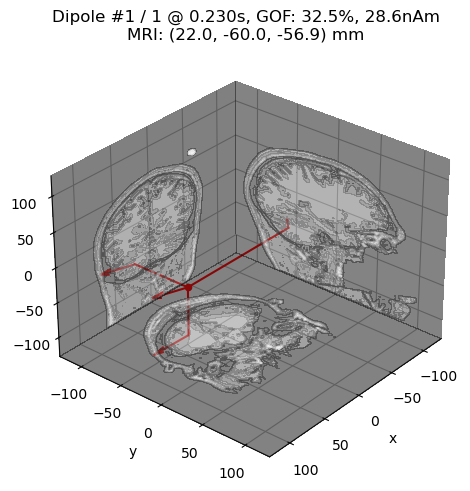

In [20]:
# Load files we created during the forward model computations
trans = mne.read_trans(f"{extra_path}/source_recon/sub-01/sub-01-trans.fif")
bem = mne.read_bem_solution(f"{extra_path}/source_recon/sub-01/sub-01-bem.fif")
subjects_dir = f"{extra_path}/freesurfer"

# Time at which to fit the dipole
fit_time = 0.23
dip, residual = mne.fit_dipole(evoked_all.copy().crop(fit_time, fit_time),
                               bem=bem, trans=trans, cov=noise_cov, rank="info",
                               verbose=False)
dip.plot_locations(trans=trans, subject="sub-01", subjects_dir=subjects_dir);

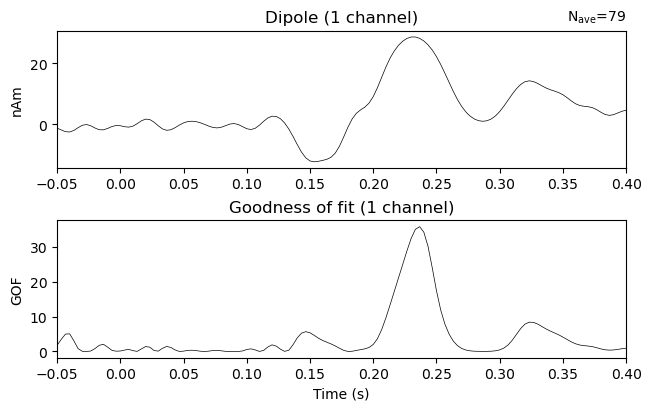

In [21]:
dip_timecourse, residual = mne.fit_dipole(evoked_all, cov=noise_cov, bem=bem,
                                          trans=trans, rank="info", verbose=False,
                                          pos=dip.pos[0], ori=dip.ori[0])
dip_timecourse.plot();

## Compute MNE inverse operator and apply to evoked data

To perform distributed source estimation such as MNE, we need to read the forward model that we had saved before.

In [ ]:
fwd = mne.read_forward_solution(f"{extra_path}/source_recon/sub-01/sub-01-meg-fwd.fif")

# Restrict forward solution to MEG channels only
fwd = mne.pick_types_forward(fwd, meg=True, eeg=False)

In [ ]:
from mne.minimum_norm import make_inverse_operator, apply_inverse

Minimum norm inverse models are independant from the data (as they use just the noise covariance but not a data covariance matrix) and can therefore be precomputed and applied to the data at a later stage.

In [ ]:
info = evoked_contrast.info
inverse_operator = make_inverse_operator(info, fwd, noise_cov, loose=0.2, depth=0.8)

Now let's apply this inverse operator to our evoked contrast:

In [ ]:
method = "dSPM"  # use the MNE-dSPM method
snr = 3.
lambda2 = 1. / snr ** 2  # regularization

stc_face = apply_inverse(evoked_face, inverse_operator, lambda2, method=method)
stc_scrambled = apply_inverse(evoked_scrambled, inverse_operator, lambda2, method=method)

Let us plot one of the course estimates. You can explore the source reconstruction, e.g. by watching the activation as a movie.  
(keep the resulting window open for the next cell to work!)

In [ ]:
brain_face = stc_face.plot(subject="sub-01", subjects_dir=subjects_dir, hemi="both")

When we have multiple brain plots open, we can link them together. In this manner we can compare between experimental contrasts.

In [ ]:
brain_scrambled = stc_scrambled.plot(subject="sub-01", subjects_dir=subjects_dir, hemi="both")
mne.viz.link_brains([brain_face, brain_scrambled])  # link the brain plots

Of course, the most informative plot may be the contrast between conditions.
`SourceEstimate` objects support basic math operations such as addition and subtraction.

In [ ]:
stc_contrast = stc_face - stc_scrambled
stc_contrast.plot(subject="sub-01", subjects_dir=subjects_dir, hemi="both")

<div class="alert alert-success">
    <b>EXERCISE</b>:
     <ul>
      <li>What do the negative and positive activations mean in the contrast plot?</li>
      <li>Can you save a screenshot of the activity at 220 ms?</li>
    </ul>
</div>

## About source orientations

Unlike fMRI data, MEG source estimates inherently have a direction as well as magnitude for each source point. By default, MNE-Python discards the direction and only keeps the magnitude. However, it is educational and useful to explore different ways to handling the directions.

One of the options is to just keep the directions and have a `VectorSourceEstimate` object:

In [ ]:
stc_vec = apply_inverse(evoked_face, inverse_operator, lambda2, method=method, pick_ori="vector")
stc_vec.plot(subject="sub-01", subjects_dir=subjects_dir, hemi="both", initial_time=0.166)

Since the main source of MEG activity, pyramidical neurons, tend to be aligned orthogonal to the cortical surface, a useful prior is to fix the source orientation to always be in this direction. The direction is approximated by the normal vector of the 3D mesh, hence this option is called `"normal"`:

In [ ]:
stc_fixed = apply_inverse(evoked_face, inverse_operator, lambda2, method=method, pick_ori="normal")
stc_fixed.plot(subject="sub-01", subjects_dir=subjects_dir, hemi="both", initial_time=0.166)

<div class="alert alert-success">
    <b>EXERCISE</b>:
     <ul>
      <li>What do negative values mean in a source estimate where the orientation is always orthogonal to the cortex?</li>
      <li>Up to now, we have always plotted source estimates on an "inflated" brain. Plot the <code>stc_fixed</code> source estamite while specifying <code>surface="white"</code> to see the wrinkles in the cortex. Do you see the pattern of positive and negative values?</li>
    </ul>
</div>


## Morphing data to an average brain for group studies

Depending on your MNE-Python installation (how long you've been using it and for what), this might prompt a download of the *fsaverage* data. This might take a while.

In [ ]:
mne.datasets.fetch_fsaverage(subjects_dir=subjects_dir)

In [ ]:
morph = mne.compute_source_morph(stc_face, subject_from="sub-01", subject_to="fsaverage",
                                 subjects_dir=subjects_dir)
stc_fsaverage = morph.apply(stc_face)

In [ ]:
stc_fsaverage.plot(subject="fsaverage", subjects_dir=subjects_dir, hemi="both")

<div class="alert alert-success">
    <b>EXERCISE</b>:
     <ul>
      <li>Run sLORETA on the same data and compare source localizations. </li>
    </ul>
</div>


## Compute beamformer and apply to evoked data

For beamforming, we need a **data covariance matrix**.

Since we want to contrast conditions, we will compute a so-called **common spatial filter** - meaning we will use a covariance matrix that was computed on both conditions jointly. In our case, that is all data.

The data covariance changes over time, hence if we compute it over a too long stretch of data, it will become inaccurate. Since the main effects seem to happen in the first 250ms, let's restrict our data to that time window.

In [ ]:
data_cov = mne.compute_covariance(epochs, tmin=0., tmax=0.25,
                                  method='empirical', rank='info')

Now we can compute the beamformer. Since we have data from two types of sensors (magnetometers and gradiometers), we need to specify the noise covariance matrix as well. This is needed to take care of the different orders of magnitudes of the sensor types.

In [ ]:
from mne.beamformer import make_lcmv, apply_lcmv
filters = make_lcmv(epochs.info, fwd, data_cov, reg=0.05, noise_cov=noise_cov)

Much like the MNE inverse operator, we can now apply the beamfor filter to all of our conditions. Since we computed the data covariance across the 0-250ms window, let's restrict the evoked data to that window as well.

In [ ]:
stc_face = apply_lcmv(evoked=evoked_face.copy().crop(0, 0.25), filters=filters)
stc_scrambled = apply_lcmv(evoked=evoked_scrambled.copy().crop(0, 0.25), filters=filters)
stc_contrast = stc_face - stc_scrambled

Plotting one of the source estimates:

In [ ]:
stc_contrast.plot(subjects_dir=subjects_dir, subject="sub-01", hemi="both", initial_time=0.220)

<div class="alert alert-success">
    <b>EXERCISE</b>:
     <ul>
      <li>Try applying either the MNE inverse operator or the LCMV beamformer to the <code>evoked_contrast</code> object Compare the result with <code>stc_face - stc_scrambled</code>. What is different about the result and why?</li>
    </ul>
</div>